#📌 Extracción

In [2]:
import pandas as pd

# Intentamos cargar los datos
try:
    df = pd.read_csv('TelecomX_Data_Clean.csv')
    print("¡Datos cargados exitosamente!")
except Exception as e:
    print(f"Hubo un error al cargar los datos: {e}")

# Visualizar las primeras filas
df.head()

¡Datos cargados exitosamente!


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


#🔧 Transformación

### Limpieza de Columnas

In [3]:
import numpy as np

# Eliminamos 'customerID' y la columna 'index' si existe
columnas_a_eliminar = ['index', 'customerID']
df = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

print("Columnas eliminadas. Dataframe actual:")
display(df.head(3))

Columnas eliminadas. Dataframe actual:


,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46


### Encoding

In [4]:
# Mapear la variable objetivo 'Churn' a 1 (Yes) y 0 (No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separar variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Aplicar One-Hot Encoding a las variables predictoras categóricas
# drop_first=True ayuda a evitar la multicolinealidad (Dummy Variable Trap)
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Dimensiones de X después del encoding: {X_encoded.shape}")

Dimensiones de X después del encoding: (7043, 31)


### Verificación de la Proporción de Cancelación (Churn)

Proporción de Cancelación (Churn):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


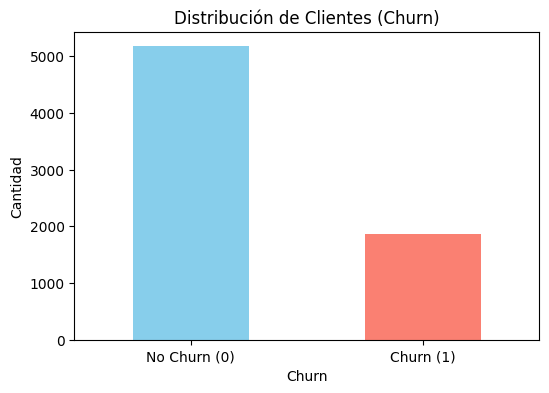

In [5]:
import matplotlib.pyplot as plt

# Proporción de la variable objetivo
proporcion_churn = y.value_counts(normalize=True) * 100
print("Proporción de Cancelación (Churn):")
print(proporcion_churn)

# Gráfico rápido para visualizarlo
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'], figsize=(6,4))
plt.title('Distribución de Clientes (Churn)')
plt.xticks([0, 1], ['No Churn (0)', 'Churn (1)'], rotation=0)
plt.ylabel('Cantidad')
plt.show()

### Normalización o Estandarización

In [6]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas (las que no fueron creadas por get_dummies)
columnas_numericas = ['customer_tenure', 'account_Charges_Monthly']

# Inicializar el escalador
scaler = StandardScaler()

# Copiar el dataframe para no alterar el original inmediatamente
X_scaled = X_encoded.copy()

# Ajustar y transformar solo las columnas numéricas
X_scaled[columnas_numericas] = scaler.fit_transform(X_scaled[columnas_numericas])

print("Datos numéricos estandarizados con éxito.")
display(X_scaled.head(3))

Datos numéricos estandarizados con éxito.


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,-0.951682,0.027862,593.30,2.19,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,-0.951682,-0.161583,542.40,2.00,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,-1.155283,0.303720,280.85,2.46,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### Balanceo de Clases con SMOTE

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# PRIMERO: Dividimos en Train y Test.
# ¡Ojo! El balanceo siempre se aplica SOLO a los datos de entrenamiento (Train)
# para evitar filtración de datos (Data Leakage).
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# SEGUNDO: Aplicamos SMOTE a los datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Distribución antes de SMOTE (Train): \n{y_train.value_counts()}")
print(f"Distribución DESPUÉS de SMOTE (Train): \n{y_train_resampled.value_counts()}")

Distribución antes de SMOTE (Train): 
Churn
0    3622
1    1308
Name: count, dtype: int64
Distribución DESPUÉS de SMOTE (Train): 
Churn
0    3622
1    3622
Name: count, dtype: int64


# 🎯 Correlación y Selección de Variables

### Análisis de Correlación

/tmp/ipykernel_307/2897528706.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlaciones.values, y=top_correlaciones.index, palette='coolwarm')


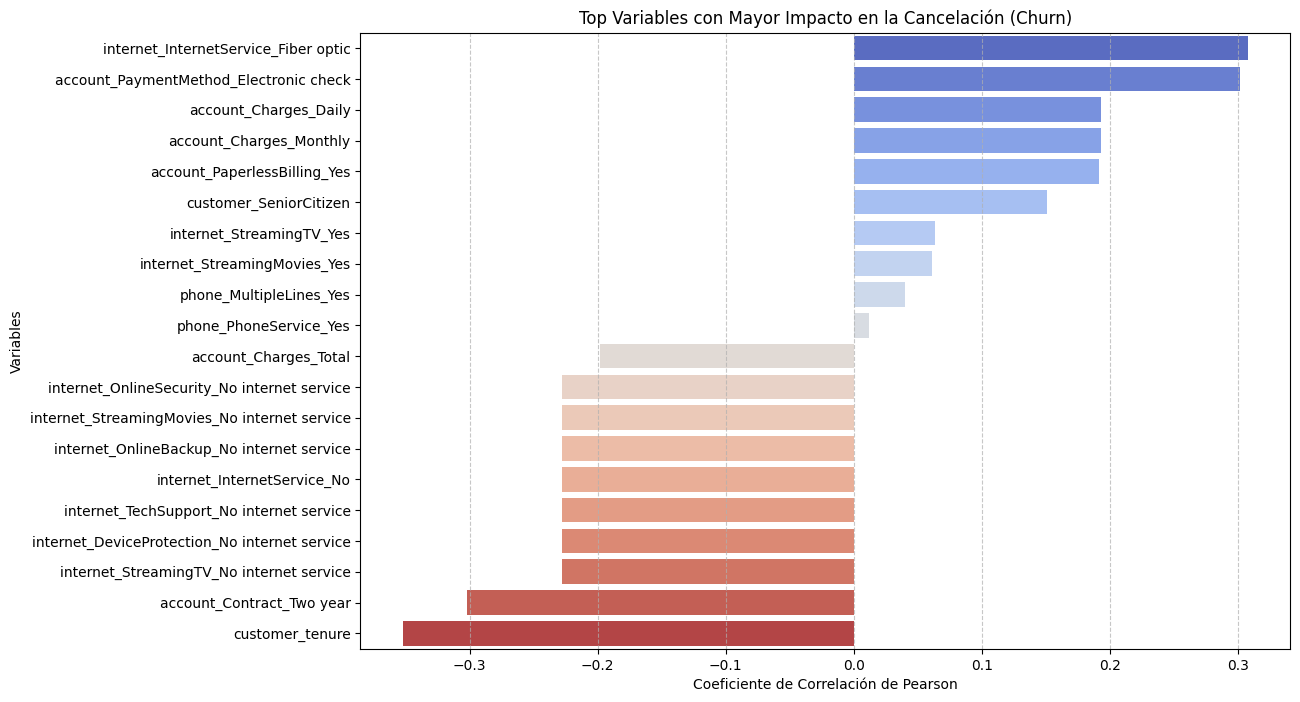

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unimos temporalmente X_encoded (antes de escalar) con 'y' para el análisis
df_eda = X_encoded.copy()
df_eda['Churn'] = y

# Calculamos la correlación de Pearson respecto a 'Churn'
correlaciones = df_eda.corr()['Churn'].sort_values(ascending=False)

# Extraemos las 10 variables con correlación positiva más alta y las 10 negativas
# (Excluimos la propia columna 'Churn' que siempre tendrá correlación 1.0)
top_positivas = correlaciones.iloc[1:11]
top_negativas = correlaciones.tail(10)
top_correlaciones = pd.concat([top_positivas, top_negativas])

# Graficamos
plt.figure(figsize=(12, 8))
sns.barplot(x=top_correlaciones.values, y=top_correlaciones.index, palette='coolwarm')
plt.title('Top Variables con Mayor Impacto en la Cancelación (Churn)')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Análisis Dirigido (Boxplots)

/tmp/ipykernel_307/709389649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='customer_tenure', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_307/709389649.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Canceló (0)', 'Sí Canceló (1)'])
/tmp/ipykernel_307/709389649.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, ax=axes[1], palette='Set1')
/tmp/ipykernel_307/709389649.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

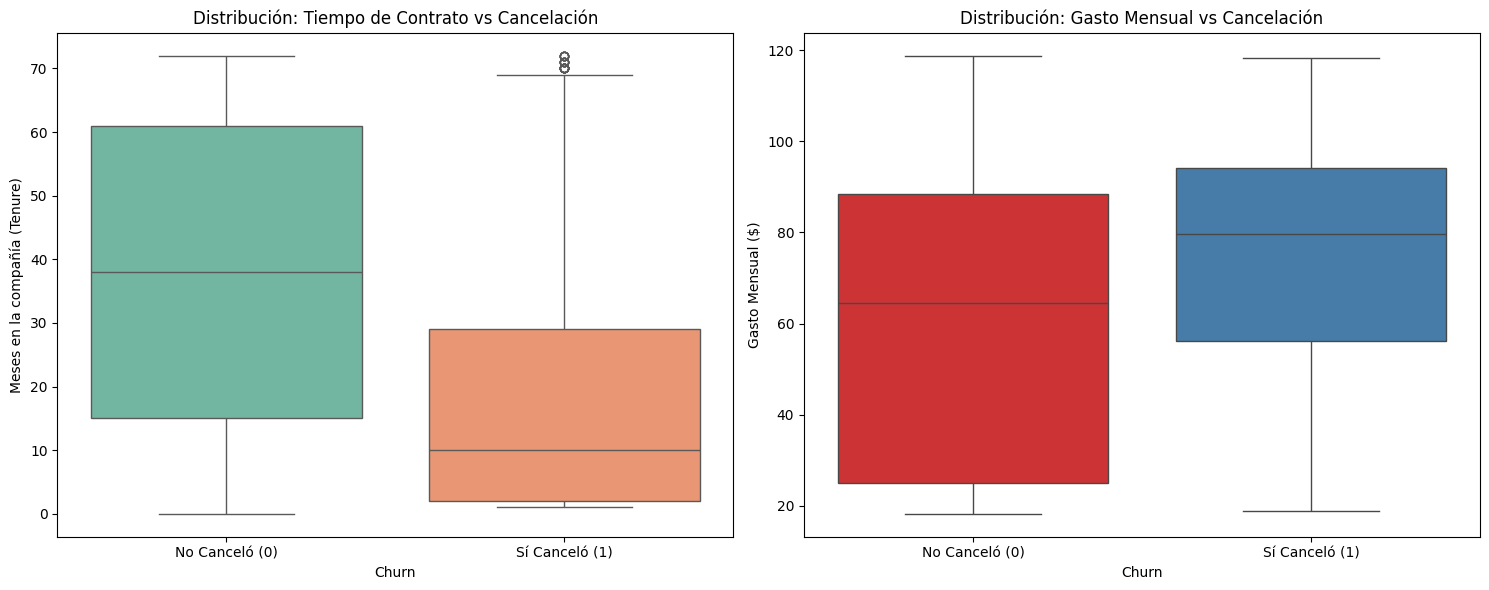

In [9]:
# Restauramos el dataframe original limpio para los gráficos dirigidos
# (usando las columnas categóricas sin codificar para que las etiquetas sean claras)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tiempo de contrato vs Cancelación
sns.boxplot(x='Churn', y='customer_tenure', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución: Tiempo de Contrato vs Cancelación')
axes[0].set_xticklabels(['No Canceló (0)', 'Sí Canceló (1)'])
axes[0].set_ylabel('Meses en la compañía (Tenure)')

# Gasto Mensual vs Cancelación
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Distribución: Gasto Mensual vs Cancelación')
axes[1].set_xticklabels(['No Canceló (0)', 'Sí Canceló (1)'])
axes[1].set_ylabel('Gasto Mensual ($)')

plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

### Separación de Datos

In [10]:
from sklearn.model_selection import train_test_split

# Definimos nuestras variables finales para el modelo
# (Asumiendo que X_scaled e y vienen del preprocesamiento anterior)
X_final = X_scaled.copy()
y_final = y.copy()

# Dividimos el conjunto de datos (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.30,
    random_state=42,
    stratify=y_final
)

# Mostramos un resumen de la división para confirmar
print("=== Resumen de la Separación de Datos ===")
print(f"Total de datos originales: {X_final.shape[0]} filas")
print(f"Datos de Entrenamiento (Train): {X_train.shape[0]} filas ({len(X_train)/len(X_final):.0%})")
print(f"Datos de Prueba (Test): {X_test.shape[0]} filas ({len(X_test)/len(X_final):.0%})")

print("\nVerificación de la proporción de Churn en el conjunto de Prueba:")
print(y_test.value_counts(normalize=True).round(3) * 100)

=== Resumen de la Separación de Datos ===
Total de datos originales: 7043 filas
Datos de Entrenamiento (Train): 4930 filas (70%)
Datos de Prueba (Test): 2113 filas (30%)

Verificación de la proporción de Churn en el conjunto de Prueba:
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


### Creación de Modelos

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Preparación de datos sin escalar para el Random Forest
# Replicamos la misma división exacta (mismo random_state) pero usando X_encoded (sin escalar)
X_train_unscaled, X_test_unscaled, _, _ = train_test_split(
    X_encoded,
    y_final,
    test_size=0.30,
    random_state=42,
    stratify=y_final
)

# 2. MODELO 1: Regresión Logística (Usando datos ESTANDARIZADOS)
# Nota: X_train fue estandarizado en los pasos anteriores
print("Entrenando Regresión Logística...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train) # Usamos X_train que proviene de X_scaled
print("✅ ¡Modelo de Regresión Logística entrenado con éxito!")

# 3. MODELO 2: Random Forest (Usando datos ORIGINALES/SIN ESCALAR)
print("\nEntrenando Random Forest...")
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_clf.fit(X_train_unscaled, y_train) # Usamos X_train_unscaled
print("✅ ¡Modelo de Random Forest entrenado con éxito!")

Entrenando Regresión Logística...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ ¡Modelo de Regresión Logística entrenado con éxito!

Entrenando Random Forest...
✅ ¡Modelo de Random Forest entrenado con éxito!


### Evalaución de Modelos

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generar predicciones para el conjunto de Prueba (Test)
y_pred_lr = log_reg.predict(X_test) # Regresión Logística (datos escalados)
y_pred_rf = rf_clf.predict(X_test_unscaled) # Random Forest (datos originales)

# Generar predicciones para el conjunto de Entrenamiento (Train) - Útil para ver Overfitting
y_train_pred_lr = log_reg.predict(X_train)
y_train_pred_rf = rf_clf.predict(X_train_unscaled)

def evaluar_modelo(nombre, y_true, y_pred, y_true_train, y_pred_train):
    print(f"--- Evaluación del Modelo: {nombre} ---")
    print(f"Exactitud (Accuracy) Test:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión (Precision):      {precision_score(y_true, y_pred):.4f}")
    print(f"Sensibilidad (Recall):      {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:                   {f1_score(y_true, y_pred):.4f}\n")

    # Verificación rápida de Overfitting
    acc_train = accuracy_score(y_true_train, y_pred_train)
    acc_test = accuracy_score(y_true, y_pred)
    print(f"Exactitud en Train: {acc_train:.4f} | Exactitud en Test: {acc_test:.4f}")
    if (acc_train - acc_test) > 0.05:
        print("⚠️ Posible OVERFITTING detectado (El modelo rinde mucho mejor en Train que en Test).")
    elif acc_train < 0.70 and acc_test < 0.70:
         print("⚠️ Posible UNDERFITTING detectado (El modelo tiene un rendimiento bajo en general).")
    else:
        print("✅ El modelo parece generalizar bien (sin señales graves de over/underfitting).")
    print("-" * 40 + "\n")

# Evaluar ambos modelos
evaluar_modelo("Regresión Logística", y_test, y_pred_lr, y_train, y_train_pred_lr)
evaluar_modelo("Random Forest", y_test, y_pred_rf, y_train, y_train_pred_rf)

--- Evaluación del Modelo: Regresión Logística ---
Exactitud (Accuracy) Test:  0.7970
Precisión (Precision):      0.6369
Sensibilidad (Recall):      0.5472
F1-Score:                   0.5887

Exactitud en Train: 0.8101 | Exactitud en Test: 0.7970
✅ El modelo parece generalizar bien (sin señales graves de over/underfitting).
----------------------------------------

--- Evaluación del Modelo: Random Forest ---
Exactitud (Accuracy) Test:  0.7946
Precisión (Precision):      0.6408
Sensibilidad (Recall):      0.5152
F1-Score:                   0.5711

Exactitud en Train: 0.8757 | Exactitud en Test: 0.7946
⚠️ Posible OVERFITTING detectado (El modelo rinde mucho mejor en Train que en Test).
----------------------------------------



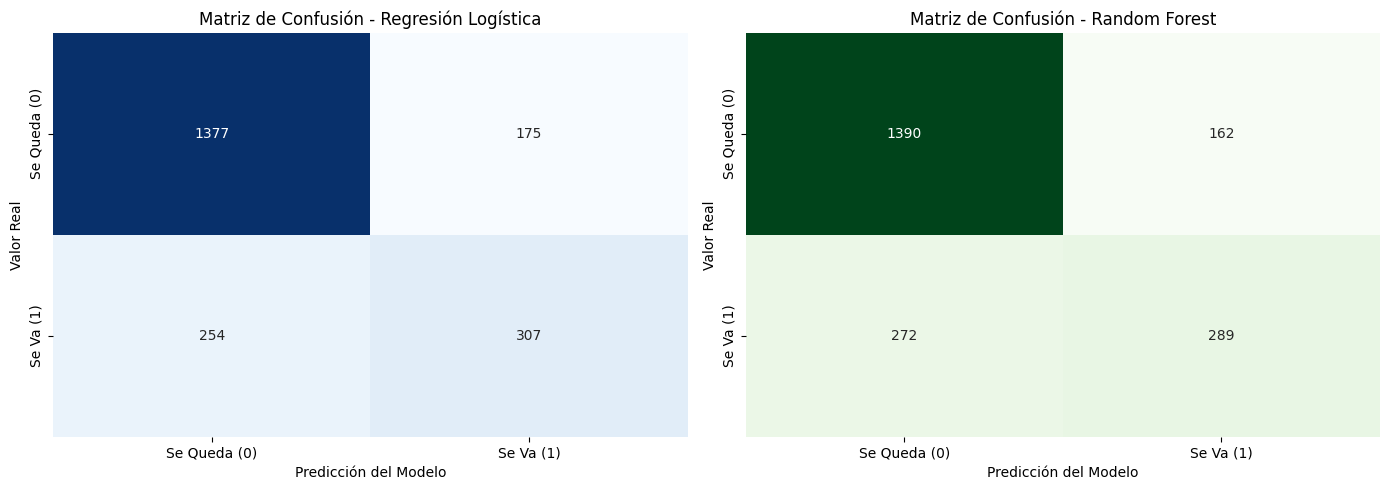

In [13]:
# Graficar Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz para Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión - Regresión Logística')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real')
axes[0].set_xticklabels(['Se Queda (0)', 'Se Va (1)'])
axes[0].set_yticklabels(['Se Queda (0)', 'Se Va (1)'])

# Matriz para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión - Random Forest')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real')
axes[1].set_xticklabels(['Se Queda (0)', 'Se Va (1)'])
axes[1].set_yticklabels(['Se Queda (0)', 'Se Va (1)'])

plt.tight_layout()
plt.show()

# 📋 Interpretación y Conclusiones

### Análisis de la Importancia de Variables

/tmp/ipykernel_307/2855286175.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancia_lr, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_307/2855286175.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia_rf, ax=axes[1], palette='viridis')


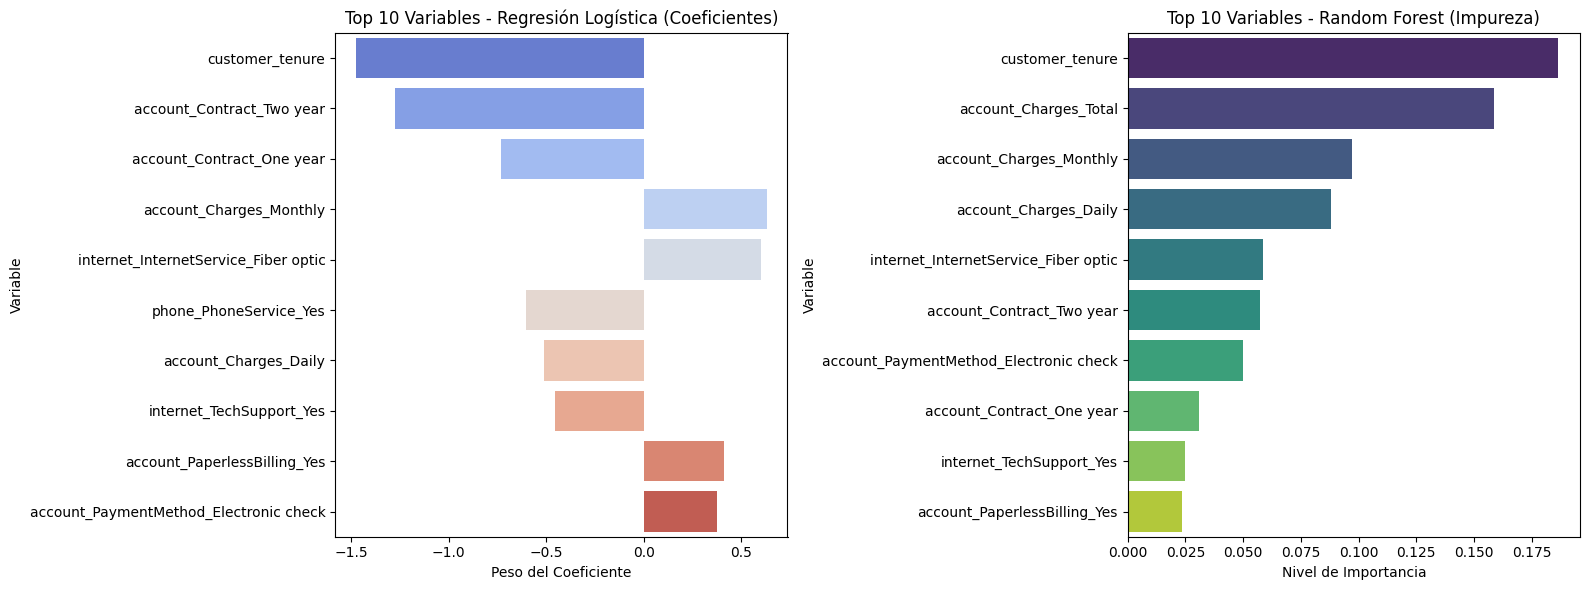

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Importancia en Regresión Logística (Coeficientes)
# Obtenemos los nombres de las variables de nuestro conjunto de entrenamiento
variables = X_train.columns
coeficientes = log_reg.coef_[0]

importancia_lr = pd.DataFrame({'Variable': variables, 'Coeficiente': coeficientes})
# Ordenamos por valor absoluto para ver las de mayor impacto (positivo o negativo)
importancia_lr['Abs_Coef'] = importancia_lr['Coeficiente'].abs()
importancia_lr = importancia_lr.sort_values(by='Abs_Coef', ascending=False).head(10)

# 2. Importancia en Random Forest (Feature Importances)
importancia_rf = pd.DataFrame({'Variable': variables, 'Importancia': rf_clf.feature_importances_})
importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False).head(10)

# 3. Graficar ambas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Regresión Logística
sns.barplot(x='Coeficiente', y='Variable', data=importancia_lr, ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Variables - Regresión Logística (Coeficientes)')
axes[0].set_xlabel('Peso del Coeficiente')

# Gráfico Random Forest
sns.barplot(x='Importancia', y='Variable', data=importancia_rf, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Variables - Random Forest (Impureza)')
axes[1].set_xlabel('Nivel de Importancia')

plt.tight_layout()
plt.show()

### Análisis Crítico y Comparación de Modelos

El modelo ganador es la **Regresión Logística**. Aunque ambos tienen una Exactitud (Accuracy) casi idéntica (79.7% vs 79.4%), en un problema de *Churn* nos interesa más detectar a los clientes que se van. La Regresión Logística obtuvo una mejor **Sensibilidad (Recall) del 54.72%** (frente al 51.52% del Random Forest) y un mejor **F1-Score**. Observando la Matriz de Confusión, la Regresión Logística logró identificar a 307 clientes en riesgo de fuga, mientras que el Random Forest solo identificó a 289.

**Análisis de Overfitting / Underfitting:**
* **Regresión Logística:** Generalizó de manera excelente. Su rendimiento en Train (81%) y Test (79.7%) es muy parejo, lo que indica que aprendió los patrones sin memorizar los datos.
* **Random Forest:** Presentó un claro **Overfitting**. Obtuvo un 87.5% de exactitud en Entrenamiento, pero cayó a 79.4% en Prueba. Esto significa que el árbol se volvió demasiado complejo y memorizó la data de entrenamiento.
  * *Posible solución a futuro:* Reducir la profundidad máxima del árbol (`max_depth=5`) o aumentar el número mínimo de muestras para dividir un nodo (`min_samples_split`).

### Conclusión Estratégica (El Informe para Telecom X)

#### 1. Hallazgos Principales (Drivers de Churn):
Tras el análisis exploratorio y el modelado predictivo, hemos identificado que la cancelación de clientes no es aleatoria, sino que está fuertemente ligada a los servicios contratados y el tipo de facturación:

* **El Riesgo de la Fibra Óptica:** Los clientes con servicio de internet por Fibra Óptica (`internet_InternetService_Fiber optic`) presentan la mayor probabilidad de abandonar la empresa.
* **Fricción en Pagos:** El uso de Cheque Electrónico (`account_PaymentMethod_Electronic check`) como método de pago está altamente correlacionado con el *churn*, sugiriendo que es un proceso incómodo o propenso a olvidos que facilita la cancelación.
* **Contratos Cortos y Facturación Alta:** Los clientes con cargos mensuales altos (`account_Charges_Monthly`) y que no poseen contratos a largo plazo (la antítesis de `account_Contract_Two year`) son altamente volátiles. Por el contrario, la antigüedad (`customer_tenure`) es el factor protector más fuerte de la compañía.

#### 2. Estrategias de Retención Propuestas:
Para anticiparnos a la pérdida de clientes y mejorar la rentabilidad, sugerimos las siguientes acciones accionables:

* **Auditoría Técnica y Comercial de la Fibra Óptica:** Es urgente investigar por qué el servicio premium de la compañía está generando tanta insatisfacción. Se debe cruzar esta información con tickets de soporte técnico para verificar caídas de servicio, o analizar si el precio está fuera del mercado competitivo.
* **Migración de Método de Pago:** Lanzar una campaña de incentivos (ej. 5% de descuento en las próximas 3 facturas) para que los clientes que usan *Electronic Check* afilien sus pagos a débito automático o tarjeta de crédito, reduciendo el esfuerzo cognitivo de pago y la fricción mensual.
* **Incentivos a la Fidelidad (Upselling a contratos largos):** A los clientes que llevan entre 1 y 6 meses (periodo crítico de fuga), se les debe ofrecer un paquete de beneficios (como un *upgrade* de velocidad o streaming gratis) a cambio de firmar un contrato anual o bianual, asegurando así su retención y aumentando el *Customer Lifetime Value (CLV)*.